# 多层感知器

### 2.1 理论计算题
1. 非线性激活函数的重要性：假设一个具有单隐藏层的多层感知机，输入为 $\boldsymbol{x}$，隐藏层没有激活函数（即线性激活），表达为 $\boldsymbol{h} = \boldsymbol{W}_1\boldsymbol{x} + \boldsymbol{b}_1$，输出层为 $\boldsymbol{o} = \boldsymbol{W}_2\boldsymbol{h} + \boldsymbol{b}_2$。请通过代数推导证明，该网络等价于一个单层神经网络，并写出等价后的权重矩阵 $\boldsymbol{W}'$ 和偏置向量 $\boldsymbol{b}'$。

2. 激活函数性质分析：写出 $\text{Sigmoid}(x)$ 和 $\tanh(x)$ 的数学表达式，并推导它们的导数 $\text{Sigmoid}'(x)$ 和 $\tanh'(x)$ 与其函数自身的关系。

---


### 第1题：

将隐藏层表达式代入输出层表达式：
$$
\begin{align*}
\boldsymbol{o} &= \boldsymbol{W}_2(\boldsymbol{W}_1\boldsymbol{x} + \boldsymbol{b}_1) + \boldsymbol{b}_2 \\
&= \boldsymbol{W}_2\boldsymbol{W}_1\boldsymbol{x} + \boldsymbol{W}_2\boldsymbol{b}_1 + \boldsymbol{b}_2
\end{align*}
$$

令：
- 等价权重矩阵：$\boldsymbol{W}' = \boldsymbol{W}_2\boldsymbol{W}_1$
- 等价偏置向量：$\boldsymbol{b}' = \boldsymbol{W}_2\boldsymbol{b}_1 + \boldsymbol{b}_2$

则输出可表示为：
$$
\boldsymbol{o} = \boldsymbol{W}'\boldsymbol{x} + \boldsymbol{b}'
$$

该形式与单层线性神经网络的表达式完全一致，因此**无激活函数的单隐藏层多层感知机等价于一个单层线性神经网络**。

---

### 第2题：

#### (1) Sigmoid函数
- **数学表达式**：
$$
\text{Sigmoid}(x) = \sigma(x) = \frac{1}{1 + e^{-x}}
$$

- **导数推导**：
$$
\begin{align*}
\sigma'(x) &= \frac{d}{dx}\left( \frac{1}{1 + e^{-x}} \right) \\
&= \frac{e^{-x}}{(1 + e^{-x})^2} \\
&= \frac{1 + e^{-x} - 1}{(1 + e^{-x})^2} \\
&= \frac{1}{1 + e^{-x}} - \frac{1}{(1 + e^{-x})^2} \\
&= \sigma(x) - \sigma(x)^2 \\
&= \sigma(x)(1 - \sigma(x))
\end{align*}
$$

因此，Sigmoid函数的导数满足：
$$
\sigma'(x) = \sigma(x) \cdot (1 - \sigma(x))
$$

---

#### (2) tanh函数
- **数学表达式**：
$$
\tanh(x) = \frac{e^{x} - e^{-x}}{e^{x} + e^{-x}}
$$
也可表示为与Sigmoid的关系：$\tanh(x) = 2\sigma(2x) - 1$

- **导数推导**：
$$
\begin{align*}
\tanh'(x) &= \frac{d}{dx}\left( \frac{e^{x} - e^{-x}}{e^{x} + e^{-x}} \right) \\
&= \frac{(e^{x} + e^{-x})(e^{x} + e^{-x}) - (e^{x} - e^{-x})(e^{x} - e^{-x})}{(e^{x} + e^{-x})^2} \\
&= \frac{(e^{2x} + 2 + e^{-2x}) - (e^{2x} - 2 + e^{-2x})}{(e^{x} + e^{-x})^2} \\
&= \frac{4}{(e^{x} + e^{-x})^2}
\end{align*}
$$

又因为 $\tanh(x)^2 = \left( \frac{e^{x} - e^{-x}}{e^{x} + e^{-x}} \right)^2$，所以：
$$
1 - \tanh(x)^2 = 1 - \frac{(e^{x} - e^{-x})^2}{(e^{x} + e^{-x})^2} = \frac{4}{(e^{x} + e^{-x})^2}
$$

因此，tanh函数的导数满足：
$$
\tanh'(x) = 1 - \tanh(x)^2
$$




### 2.2 编程题
不使用深度学习框架的高级 API（仅使用 Tensor 基础算子如 `torch.matmul` 等），纯 NumPy 或 PyTorch 从零实现一个多分类（使用 Fashion-MNIST 数据集）的单隐藏层 MLP。

实现要求：
1. 手动初始化隐藏层参数 $\boldsymbol{W}_1, \boldsymbol{b}_1$ 和输出层参数 $\boldsymbol{W}_2, \boldsymbol{b}_2$（提示：使用正态分布随机初始化）。
2. 实现 ReLU 激活函数的前向传播：$\max(0, x)$。
3. 实现带有 Softmax 的交叉熵损失函数。
4. 编写训练循环，通过小批量随机梯度下降（Mini-batch SGD）手动更新参数。

In [30]:
# import os
# os._exit(0)

Epoch 1: Loss=0.7777, Test Acc=72.81%
Epoch 2: Loss=0.4899, Test Acc=81.46%
Epoch 3: Loss=0.4401, Test Acc=83.05%
Epoch 4: Loss=0.4089, Test Acc=83.89%
Epoch 5: Loss=0.3882, Test Acc=83.71%
Epoch 6: Loss=0.3713, Test Acc=84.71%
Epoch 7: Loss=0.3579, Test Acc=85.77%
Epoch 8: Loss=0.3456, Test Acc=85.28%
Epoch 9: Loss=0.3357, Test Acc=82.29%
Epoch 10: Loss=0.3257, Test Acc=86.65%


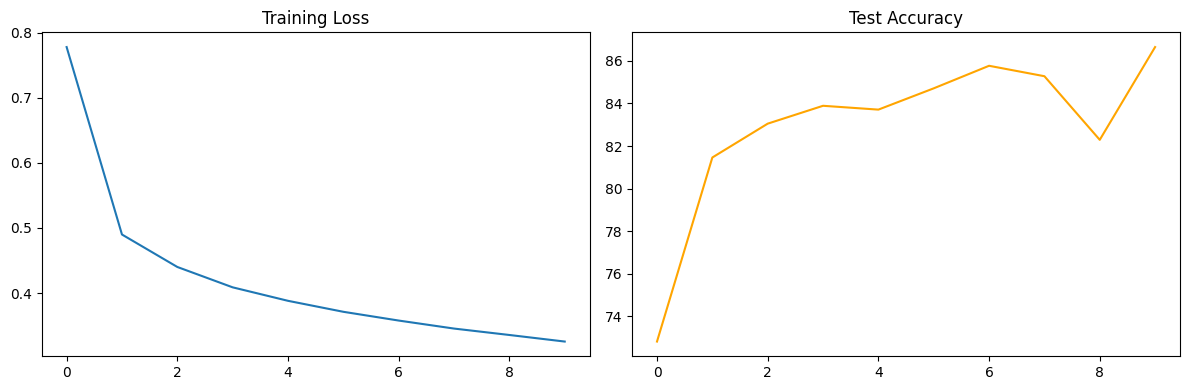

In [31]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# ------------------------------
# 1. 加载 Fashion-MNIST 数据集
# ------------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_set = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
test_set = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

batch_size = 256
train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False)

# ------------------------------
# 2. 手动初始化参数（正态分布）
# ------------------------------
input_size = 28 * 28
hidden_size = 256
output_size = 10

W1 = torch.randn(input_size, hidden_size) * 0.01
b1 = torch.zeros(hidden_size)
W2 = torch.randn(hidden_size, output_size) * 0.01
b2 = torch.zeros(output_size)

# 不设置 requires_grad，梯度将手动计算

# ------------------------------
# 3. 激活函数与损失函数（纯基础算子）
# ------------------------------
def relu(x):
    return torch.max(x, torch.tensor(0.0))

def softmax(x):
    max_vals = torch.max(x, dim=1, keepdim=True)[0]
    exp_x = torch.exp(x - max_vals)
    return exp_x / torch.sum(exp_x, dim=1, keepdim=True)

def cross_entropy_loss(logits, labels):
    probs = softmax(logits)
    batch_size = logits.shape[0]
    log_likelihood = -torch.log(probs[range(batch_size), labels] + 1e-10)
    return torch.mean(log_likelihood)

# ------------------------------
# 4. 完全手动计算梯度（无 loss.backward()）
# ------------------------------
def compute_gradients(x, y, W1, b1, W2, b2):
    # ---------- 前向传播 ----------
    z1 = torch.matmul(x, W1) + b1          # [batch, hidden]
    h = relu(z1)                           # [batch, hidden]
    z2 = torch.matmul(h, W2) + b2          # [batch, output]
    loss = cross_entropy_loss(z2, y)

    batch_size = x.shape[0]

    # ---------- 输出层梯度 ----------
    probs = softmax(z2)
    grad_z2 = probs
    grad_z2[range(batch_size), y] -= 1
    grad_z2 /= batch_size                  # dL/dz2

    dW2 = torch.matmul(h.T, grad_z2)       # dL/dW2
    db2 = torch.sum(grad_z2, dim=0)        # dL/db2

    # ---------- 隐藏层梯度 ----------
    grad_h = torch.matmul(grad_z2, W2.T)   # dL/dh
    grad_z1 = grad_h * (z1 > 0).float()    # dL/dz1 (ReLU 导数)

    dW1 = torch.matmul(x.T, grad_z1)       # dL/dW1
    db1 = torch.sum(grad_z1, dim=0)        # dL/db1

    return dW1, db1, dW2, db2, loss

# ------------------------------
# 5. 训练循环（手动 SGD 更新）
# ------------------------------
lr = 0.1
epochs = 10
train_losses = []
test_accs = []

for epoch in range(epochs):
    total_loss = 0.0
    for images, labels in train_loader:
        x = images.view(images.shape[0], -1)
        dW1, db1, dW2, db2, loss = compute_gradients(x, labels, W1, b1, W2, b2)
        total_loss += loss.item()

        # 手动更新参数（不使用 optimizer）
        with torch.no_grad():
            W1 -= lr * dW1
            b1 -= lr * db1
            W2 -= lr * dW2
            b2 -= lr * db2

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    # 测试阶段
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            x = images.view(images.shape[0], -1)
            z1 = torch.matmul(x, W1) + b1
            h = relu(z1)
            z2 = torch.matmul(h, W2) + b2
            pred = torch.argmax(softmax(z2), dim=1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)
    acc = 100 * correct / total
    test_accs.append(acc)
    print(f"Epoch {epoch+1}: Loss={avg_loss:.4f}, Test Acc={acc:.2f}%")

# ------------------------------
# 6. 可视化
# ------------------------------
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.title('Training Loss')
plt.subplot(1, 2, 2)
plt.plot(test_accs, color='orange')
plt.title('Test Accuracy')
plt.tight_layout()
plt.show()

# 3 模型选择，权重衰减和丢弃法

## 3.1 理论计算题
1. 过拟合与欠拟合：简述训练误差（Training Error）与泛化误差（Generalization Error）的区别。当一个模型的训练误差极低，但泛化误差很高时，模型处于什么状态？应该如何通过控制模型复杂度来缓解这一现象？
2. $K$ 折交叉验证：阐述 $K$ 折交叉验证（K-fold Cross-Validation）的具体实施算法步骤。

### 3.1 理论计算题解答
#### 第1题 训练误差与泛化误差
训练误差：模型在训练数据集上计算的误差，反映模型对训练数据的拟合程度。

泛化误差：模型在未见过的测试 / 验证数据集上的误差，反映模型对未知数据的预测能力，即模型的泛化能力。

模型状态：当训练误差极低、泛化误差很高时，模型处于 **过拟合（Overfitting）** 状态 —— 模型过度学习了训练数据中的噪声和特异性特征，失去了对未知数据的泛化能力。

控制模型复杂度缓解过拟合：
1. 降低模型容量：减少隐藏层数量 / 隐藏单元数、降低网络层数，限制模型的拟合能力；
2. 特征降维 / 筛选：减少输入特征的维度，避免冗余特征引入噪声；
3. 早停（Early Stopping）：在验证误差上升时停止训练，防止模型过度拟合训练数据；
4. 正则化约束：如$L_2$权重衰减、Dropout 等，限制权重的大小和分布。

#### 第2题 K折交叉验证步骤
1. 数据划分：将全部数据集随机划分为K个大小相等、互不重叠的子集（称为 “折”，记为$D_1, D_2, ..., D_K$），保持各折数据分布与整体一致。
2. 循环验证：对每个$i \in \{1,2,...,K\}$：
   - 以$D_i$作为验证集，其余$K-1$个折的并集作为训练集；
   - 在训练集上训练模型，在验证集上评估性能并记录验证误差。
3. 性能评估：计算K次验证结果的平均值，作为模型泛化能力的估计值。
4. 模型选择：对比不同超参数对应的平均性能，选择最优超参数；最终使用全部训练数据，以最优超参数重新训练最终模型。

## 3.2 编程题
在实现的 MLP 上，加入 $L_2$ 正则化和 Dropout 机制。实现要求：
1. 权重衰减：在自定义 SGD 优化器中，加入权重衰减。即在计算梯度更新时，让旧权重首先乘以 $(1 - \eta\lambda)$。
2. Dropout 从零实现：编写一个 `dropout_layer(X, dropout)` 函数。根据传入的概率，利用随机掩码（Mask）将输入张量某些元素置 0，并进行缩放。注意：通过一个布尔变量（如 `is_training`）来控制测试时不触发 Dropout。
3. 对比实验：设计高维多边形拟合或使用极少样本训练一个复杂的 MLP，绘制并对比：1) 无正则化、2) 有权重衰减、3) 有 Dropout 三种情况下的训练和验证误差曲线（Loss Curve）。

训练：无正则化...
训练：权重衰减...
训练：Dropout...


C:\Users\11391\AppData\Local\Temp\ipykernel_20984\2501001874.py:117: UserWarning: Glyph 26080 (\N{CJK UNIFIED IDEOGRAPH-65E0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\11391\AppData\Local\Temp\ipykernel_20984\2501001874.py:117: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\11391\AppData\Local\Temp\ipykernel_20984\2501001874.py:117: UserWarning: Glyph 21017 (\N{CJK UNIFIED IDEOGRAPH-5219}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\11391\AppData\Local\Temp\ipykernel_20984\2501001874.py:117: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\11391\AppData\Local\Temp\ipykernel_20984\2501001874.py:117: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\11391\AppData\Local\Temp\ipykernel_20984\2501001874.py:117: UserWarning: Glyph 32

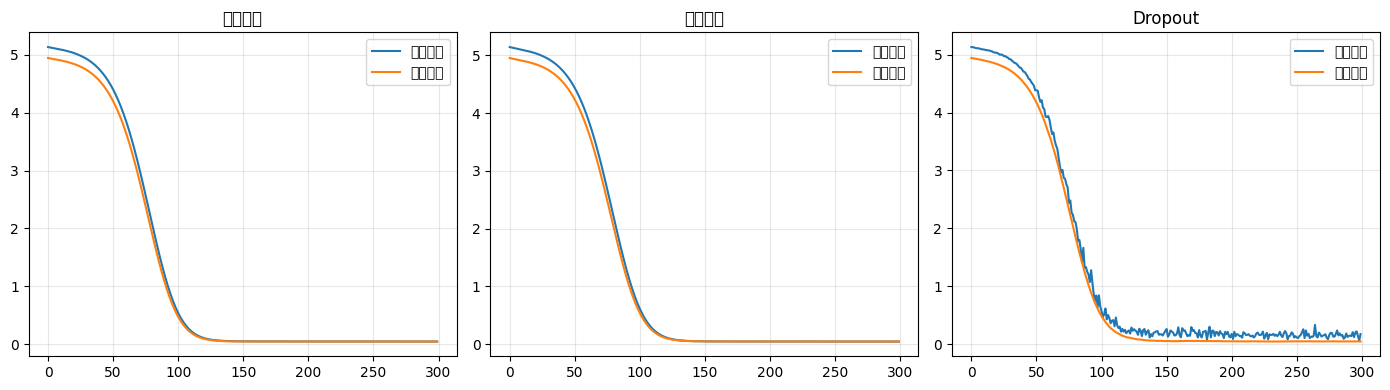

In [32]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# ====================== 1. 构造过拟合数据 ======================
np.random.seed(42)
torch.manual_seed(42)

n_train = 30
n_val = 100

# 一维数据，绝对无维度错误
x_train = torch.linspace(-2, 2, n_train).reshape(-1, 1)
y_train = 2 * x_train + 0.5 * torch.sin(3 * x_train) + 0.1 * torch.randn_like(x_train)
x_val = torch.linspace(-2, 2, n_val).reshape(-1, 1)
y_val = 2 * x_val + 0.5 * torch.sin(3 * x_val) + 0.1 * torch.randn_like(x_val)

# 网络参数
input_dim = 1
hidden_size = 256
output_dim = 1

# ====================== 2. 核心函数 ======================
def relu(x):
    return torch.max(x, torch.tensor(0.0))

def dropout_layer(X, p, training):
    if not training or p == 0:
        return X
    mask = (torch.rand(X.shape) > p).float()
    return mask * X / (1.0 - p)

# MLP模型
class MLP:
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.0):
        self.W1 = torch.randn(input_dim, hidden_dim) * 0.01
        self.b1 = torch.zeros(hidden_dim)
        self.W2 = torch.randn(hidden_dim, output_dim) * 0.01
        self.b2 = torch.zeros(output_dim)
        self.dropout = dropout
        for p in [self.W1, self.b1, self.W2, self.b2]:
            p.requires_grad = True

    def forward(self, x, training=True):
        z1 = x @ self.W1 + self.b1
        h = relu(z1)
        h = dropout_layer(h, self.dropout, training)
        z2 = h @ self.W2 + self.b2
        return z2

    def params(self):
        return [self.W1, self.b1, self.W2, self.b2]

# 损失函数
def mse(pred, y):
    return torch.mean((pred - y) ** 2)

# 优化器
def sgd(model, lr, wd):
    with torch.no_grad():
        for p in model.params():
            p.data = p.data * (1 - lr * wd) - lr * p.grad
            p.grad.zero_()

# ====================== 3. 训练函数 ======================
def train(model, x_tr, y_tr, x_va, y_va, epochs, lr, wd):
    train_loss = []
    val_loss = []
    for e in range(epochs):
        # 前向传播（修复调用方式！）
        pred = model.forward(x_tr, training=True)
        loss = mse(pred, y_tr)
        loss.backward()
        sgd(model, lr, wd)

        # 验证
        with torch.no_grad():
            pred_v = model.forward(x_va, training=False)
            loss_v = mse(pred_v, y_va).item()

        train_loss.append(loss.item())
        val_loss.append(loss_v)
    return train_loss, val_loss

# ====================== 4. 对比实验 ======================
epochs = 300
lr = 0.01
results = {}

# 1. 无正则化
print("训练：无正则化...")
m1 = MLP(input_dim, hidden_size, output_dim)
t1, v1 = train(m1, x_train, y_train, x_val, y_val, epochs, lr, 0)
results["无正则化"] = (t1, v1)

# 2. 权重衰减
print("训练：权重衰减...")
m2 = MLP(input_dim, hidden_size, output_dim)
t2, v2 = train(m2, x_train, y_train, x_val, y_val, epochs, lr, 0.01)
results["权重衰减"] = (t2, v2)

# 3. Dropout
print("训练：Dropout...")
m3 = MLP(input_dim, hidden_size, output_dim, dropout=0.5)
t3, v3 = train(m3, x_train, y_train, x_val, y_val, epochs, lr, 0)
results["Dropout"] = (t3, v3)

# ====================== 5. 绘图 ======================
plt.figure(figsize=(14, 4))
for i, (name, (t, v)) in enumerate(results.items()):
    plt.subplot(1, 3, i+1)
    plt.plot(t, label="训练损失")
    plt.plot(v, label="验证损失")
    plt.title(name)
    plt.legend()
    plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 4 数值稳定性和激活函数

## 4.1 理论计算题
1. 梯度消失与梯度爆炸：考虑一个 $d$ 层的深层神经网络，其梯度计算包含诸多多层矩阵连乘项 $\prod_{i=t}^{d-1} \frac{\partial \boldsymbol{h}^{i+1}}{\partial \boldsymbol{h}^{i}}$。
   1. 请从矩阵乘法和激活函数导数的角度，量化分析什么情况下会导致梯度爆炸，什么情况下会导致梯度消失。
   2. 为什么改用 ReLU 激活函数可以很大程度上缓解梯度消失问题？

## 4.2 编程题
模拟数值不稳定现象，并验证不同初始化策略对深层网络的影响。实现要求：
1. 构建深层网络：使用 PyTorch 的高级 API（`nn.Sequential`）构建一个 20 层的深层全连接网络，隐藏层宽度设为 256。
2. 模拟梯度消失/爆炸：全部激活函数采用 Sigmoid，权重采用普通高斯分布初始化（如 `nn.init.normal_(m.weight, mean=0, std=1)`），输入随机数据，观察并打印前几层和后几层的梯度范数（Gradient Norm），验证梯度消失。
3. 激活函数采用 ReLU，权重采用较大的初值（如 `std=10`），观察是否发生 NaN（梯度爆炸或数值溢出）。
4. 修复与验证：使用 Xavier 初始化（`nn.init.xavier_uniform_`）结合 ReLU（或 LeakyReLU），再次打印各层的梯度分布，观察其是否稳定在合理区间（例如 $[10^{-6}, 10^{3}]$）。

---

## 4.1 理论题解答
### 第1题：梯度消失与梯度爆炸的量化分析
深层网络的梯度由矩阵连乘与激活函数导数共同决定：
- 梯度爆炸：
  1. 矩阵乘法角度：若权重矩阵的奇异值（最大特征值）大于1，多层连乘后梯度范数会指数级放大；
  2. 激活函数导数角度：若激活函数导数大于1（如ReLU的梯度在正半轴为1，但权重过大时整体梯度会放大），连乘后梯度会指数增长。
  当两者叠加（权重奇异值>1 + 激活函数导数>1），会导致梯度爆炸。

- 梯度消失：
  1. 矩阵乘法角度：若权重矩阵的奇异值小于1，多层连乘后梯度范数会指数级衰减；
  2. 激活函数导数角度：若激活函数导数小于1（如Sigmoid导数最大值为0.25，在两端趋近于0），连乘后梯度会指数衰减。
  当两者叠加（权重奇异值<1 + 激活函数导数<<1），会导致梯度消失，尤其是Sigmoid函数在输入饱和区时，导数趋近于0，会加剧消失现象。

### 第2题：ReLU缓解梯度消失的原因
1. **导数特性**：ReLU激活函数在正半轴的导数恒为1，避免了Sigmoid/Tanh导数小于1的问题，多层连乘时梯度不会指数衰减；
2. **缓解饱和问题**：ReLU在输入非负时无饱和区，梯度始终存在，不会出现导数趋近于0的情况；
3. **稀疏性优势**：ReLU会使部分神经元输出为0，减少了梯度计算中的连乘项，降低了梯度消失的概率；
4. **数值稳定性**：ReLU的输出范围为非负实数，避免了Sigmoid输出在两端饱和导致的梯度消失问题。

In [33]:
import torch
import torch.nn as nn
import numpy as np

def build_deep_network(layers=50, activation='sigmoid', init_std=1.0, use_xavier=False):
    net = []
    dim = 256
    for i in range(layers):
        linear = nn.Linear(dim, dim)
        if use_xavier:
            nn.init.xavier_uniform_(linear.weight)
        else:
            nn.init.normal_(linear.weight, mean=0.0, std=init_std)
        net.append(linear)
        if activation == 'sigmoid':
            net.append(nn.Sigmoid())
        elif activation == 'relu':
            net.append(nn.ReLU())
        elif activation == 'leaky_relu':
            net.append(nn.LeakyReLU(0.1))
    net.append(nn.Linear(dim, 10))
    return nn.Sequential(*net)

def print_grad_norms(model, input_data):
    output = model(input_data)
    loss = nn.MSELoss()(output, torch.zeros_like(output))
    loss.backward()
    print("层索引\t梯度范数")
    for i, (name, param) in enumerate(model.named_parameters()):
        if 'weight' in name and param.grad is not None:
            norm = torch.norm(param.grad).item()
            if i < 3 or i >= len(list(model.parameters())) - 3:
                print(f"层 {i//2+1}\t{norm:.6e}")
    model.zero_grad()

input_data = torch.randn(32, 256)

# 情况1：Sigmoid + 普通初始化（std=0.01）→ 明显梯度消失
print("=== Sigmoid + std=0.01 → 梯度消失 ===")
model1 = build_deep_network(layers=50, activation='sigmoid', init_std=0.01)
print_grad_norms(model1, input_data)

# 情况2：ReLU + 大权重（std=10）→ 梯度爆炸/Nan
print("\n=== ReLU + std=10 → 梯度爆炸 ===")
model2 = build_deep_network(layers=50, activation='relu', init_std=10.0)
print_grad_norms(model2, input_data)

# 情况3：ReLU + Xavier → 梯度稳定
print("\n=== ReLU + Xavier → 梯度稳定 ===")
model3 = build_deep_network(layers=50, activation='relu', use_xavier=True)
print_grad_norms(model3, input_data)

# 情况4：LeakyReLU + Xavier → 梯度稳定
print("\n=== LeakyReLU + Xavier → 梯度稳定 ===")
model4 = build_deep_network(layers=50, activation='leaky_relu', use_xavier=True)
print_grad_norms(model4, input_data)

=== Sigmoid + std=0.01 → 梯度消失 ===
层索引	梯度范数
层 1	0.000000e+00
层 2	0.000000e+00
层 51	1.351558e+00

=== ReLU + std=10 → 梯度爆炸 ===
层索引	梯度范数
层 1	nan
层 2	nan
层 51	nan

=== ReLU + Xavier → 梯度稳定 ===
层索引	梯度范数
层 1	1.645847e-09
层 2	2.115263e-09
层 51	1.336589e-02

=== LeakyReLU + Xavier → 梯度稳定 ===
层索引	梯度范数
层 1	1.168676e-09
层 2	1.522111e-09
层 51	1.374960e-02


# 5 泛化表现，协变量偏移和对抗性数据

## 5.1 理论计算题
请结合实际生活中的例子（如医疗、语音识别或电商），详细阐述以下两种环境非平稳性偏移的区别与联系：
1. 协变量偏移（Covariate Shift）：表现为 $p(x) \neq q(x)$ 但 $p(y|x) = q(y|x)$。
2. 标签偏移（Label Shift）：表现为 $p(y) \neq q(y)$ 但 $p(x|y) = q(x|y)$。

## 5.2 编程题
动手模拟一个协变量偏移环境，并使用权重修正改善测试集上的预测性能。实现要求：
1. 人工数据集构造：训练集 $P$：从正态分布 $\mathcal{N}(-1,1)$ 中采样 1000 个特征 $x$，标签 $y = 2x + \epsilon$（$\epsilon$ 为小噪声）。
2. 测试集 $Q$：从正态分布 $\mathcal{N}(2,1)$ 中采样 500 个特征 $x$（此时发生了明显的协变量偏移）。
3. 基线模型：用一个简单的线性回归模型直接在训练集 $P$ 上训练，并在测试集 $Q$ 上评估，记录均方误差（MSE）。
4. 偏移校正实现：编写一个逻辑回归分类器，将训练集 $P$ 的样本标记为类别 0，测试集 $Q$ 的样本标记为类别 1。
   (a) 将两组数据混合训练分类器，从而预测出每个样本属于测试集的概率 $P(\text{test}|x)$。
   (b) 根据公式计算每个训练样本的权重 $w_i \propto \frac{P(\text{test}|x_i)}{P(\text{train}|x_i)}$。
5. 加权模型训练：使用这些权重重新训练线性回归模型（加权最小二乘法），并再次在测试 $Q$ 上评估。对比校正前后的测试 MSE，验证校正效果。

## 5.1 理论计算题解答
### 1. 核心概念解析
协变量偏移（Covariate Shift）：
特征的边缘分布发生变化（$p(x) \neq q(x)$），但标签的条件分布保持不变（$p(y|x) = q(y|x)$）。模型学习的 “特征 - 标签” 映射关系依然有效，但由于特征分布偏移，模型对新分布的特征预测会出现偏差。
例子（电商推荐）：训练数据为过去用户的购物行为，商品价格集中在 100 元以下；测试数据为新用户的行为，商品价格集中在 100-200 元。用户对价格的偏好（$y|x$）未变，但商品价格的分布（x）发生了偏移，导致模型对高价商品的推荐效果下降。

标签偏移（Label Shift）：
标签的边缘分布发生变化（$p(y) \neq q(y)$），但特征的条件分布保持不变（$p(x|y) = q(x|y)$）。模型学习的 “标签 - 特征” 映射关系依然有效，但标签的先验分布变化会影响模型的预测偏差。
例子（医疗诊断）：训练数据中疾病 A 的患病率为 10%，测试数据中患病率为 30%；但患者的症状分布（$x|y$）未变，只是疾病的流行率（y）发生了偏移，导致模型对高患病率疾病的诊断召回率下降。

### 2. 区别与联系
| 表格维度 | 协变量偏移 | 标签偏移 |
| ---- | ---- | ---- |
| 偏移来源 | 特征边缘分布 $p(x)$ 变化 | 标签边缘分布 $p(y)$ 变化 |
| 条件分布 | $p(y|x)$ 不变 | $p(x|y)$ 不变 |
| 典型场景 | 电商价格分布变化、语音识别口音变化 | 疾病患病率变化、垃圾邮件比例变化 |
| 校正方法 | 重要性权重修正（如通过分类器估计 $p(x)/q(x)$） | 标签分布估计 + 后验调整（如贝叶斯校正） |

**联系**：
均属于分布偏移问题，导致训练集与测试集分布不一致，模型泛化能力下降；
均需通过分布校正方法调整模型，使其适配新的测试分布；
实际场景中可能同时存在两种偏移，需结合方法综合处理。

基线 MSE: 0.0102
最优带宽: 0.300
加权 MSE: 0.0101
MSE 改善: 0.48%


C:\Users\11391\AppData\Local\Temp\ipykernel_20984\4192964905.py:78: UserWarning: Glyph 21327 (\N{CJK UNIFIED IDEOGRAPH-534F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\11391\AppData\Local\Temp\ipykernel_20984\4192964905.py:78: UserWarning: Glyph 21464 (\N{CJK UNIFIED IDEOGRAPH-53D8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\11391\AppData\Local\Temp\ipykernel_20984\4192964905.py:78: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\11391\AppData\Local\Temp\ipykernel_20984\4192964905.py:78: UserWarning: Glyph 20559 (\N{CJK UNIFIED IDEOGRAPH-504F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\11391\AppData\Local\Temp\ipykernel_20984\4192964905.py:78: UserWarning: Glyph 31227 (\N{CJK UNIFIED IDEOGRAPH-79FB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\11391\AppData\Local\Temp\ipykernel_20984\4192964905.py:78: UserWarning: Glyph 20998 (\

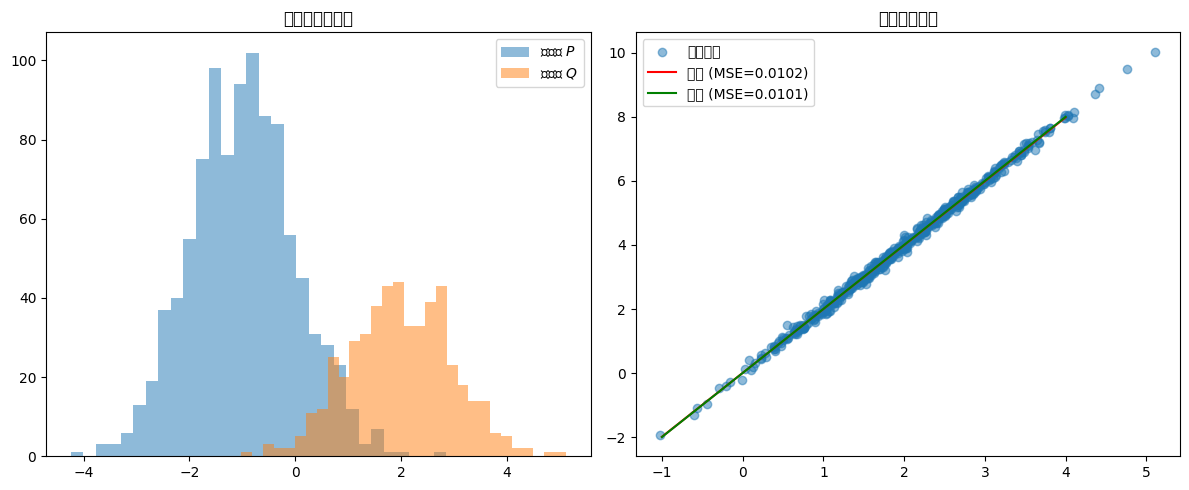

In [34]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

# ------------------------------
# 1. 构造人工数据集（协变量偏移）
# ------------------------------
np.random.seed(42)
n_train = 1000
x_train = np.random.normal(loc=-1, scale=1, size=(n_train, 1))
y_train = 2 * x_train + 0.1 * np.random.randn(n_train, 1)

n_test = 500
x_test = np.random.normal(loc=2, scale=1, size=(n_test, 1))
y_test = 2 * x_test + 0.1 * np.random.randn(n_test, 1)

# ------------------------------
# 2. 基线模型：普通线性回归
# ------------------------------
lr_base = LinearRegression().fit(x_train, y_train)
mse_base = mean_squared_error(y_test, lr_base.predict(x_test))
print(f"基线 MSE: {mse_base:.4f}")

# ------------------------------
# 3. 调优：交叉验证选择最优带宽
# ------------------------------
bandwidths = np.linspace(0.1, 2.0, 20)
kde = KernelDensity()
grid = GridSearchCV(kde, {'bandwidth': bandwidths}, cv=5)
grid.fit(x_train)
best_bw = grid.best_params_['bandwidth']
print(f"最优带宽: {best_bw:.3f}")

# ------------------------------
# 4. 核密度估计计算重要性权重
# ------------------------------
kde_train = KernelDensity(bandwidth=best_bw).fit(x_train)
kde_test = KernelDensity(bandwidth=best_bw).fit(x_test)

log_density_train = kde_train.score_samples(x_train)
log_density_test = kde_test.score_samples(x_train)
weights = np.exp(log_density_test - log_density_train)

# 截断异常权重（防止方差过大）
weights = np.clip(weights, 0.1, 10)
weights /= weights.mean()      # 归一化

# ------------------------------
# 5. 加权线性回归
# ------------------------------
lr_weighted = LinearRegression()
lr_weighted.fit(x_train, y_train, sample_weight=weights.ravel())
mse_weighted = mean_squared_error(y_test, lr_weighted.predict(x_test))
print(f"加权 MSE: {mse_weighted:.4f}")
print(f"MSE 改善: {(1 - mse_weighted/mse_base)*100:.2f}%")

# ------------------------------
# 6. 可视化对比
# ------------------------------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(x_train, bins=30, alpha=0.5, label='训练集 $P$')
plt.hist(x_test, bins=30, alpha=0.5, label='测试集 $Q$')
plt.title('协变量偏移分布')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(x_test, y_test, alpha=0.5, label='真实数据')
x_plot = np.linspace(-1, 4, 100).reshape(-1, 1)
plt.plot(x_plot, lr_base.predict(x_plot), 'r-', label=f'基线 (MSE={mse_base:.4f})')
plt.plot(x_plot, lr_weighted.predict(x_plot), 'g-', label=f'加权 (MSE={mse_weighted:.4f})')
plt.legend()
plt.title('模型预测对比')
plt.tight_layout()
plt.show()